# A2 · 貝葉斯生存分析(一):刪失的似然

> **核心問題**:追蹤期結束時**還活著**的病人,這筆資料不是「沒事件」,是「我還不知道」。
> 這種**右刪失(right censoring)**怎麼進入似然?

這本 notebook 處理專案的靈魂與前兩個通關標準:

1. 刪失似然的推導、手刻,以及與 `pm.Censored` 的等價驗證
2. **通關標準 1**:忽略刪失 → 存活時間被系統性低估
3. **通關標準 2**:貝葉斯個體存活曲線帶不確定性帶,Cox 只給一條線

第二本(`02_model_comparison_and_information.ipynb`)處理模型比較與刪失的資訊代價。

資料是 **GBSG2**(German Breast Cancer Study Group 2):686 位淋巴結陽性乳癌病人,
追蹤至多 7.3 年,**56.4% 右刪失**。

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
import arviz as az
from IPython.display import Image, display
import data as D, censoring as cn, models as M, frequentist as fq, evaluate as ev
DATA = os.path.abspath('../../data/A_medical')
FIG  = os.path.abspath('../figures')
RES  = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
print('results.json from a', RES['_meta']['runtime_sec'], 'sec full run')


results.json from a 389.9 sec full run


## 1. 資料:刪失者與事件者的追蹤時間完全不同

先看一個關鍵事實。它決定了「把刪失當成事件」會往哪個方向錯。

In [2]:
s, scaler = D.load(DATA)
print(s.summary())
print()
print(f"事件者的中位觀察時間  : {np.median(s.t[s.event==1]):.2f} 年")
print(f"刪失者的中位追蹤時間  : {np.median(s.t[s.event==0]):.2f} 年")
print()
print("→ 刪失者被觀察得更久卻還沒發生事件,他們是**活得比較久**的那群人。")
print("  把他們當成『在追蹤結束時死亡』,等於系統性把存活時間往下拉。")
display(s.df_raw.head())

n=686, events=299, censored=387 (56.4%), follow-up 0.02–7.28 yr

事件者的中位觀察時間  : 1.77 年
刪失者的中位追蹤時間  : 3.95 年

→ 刪失者被觀察得更久卻還沒發生事件,他們是**活得比較久**的那群人。
  把他們當成『在追蹤結束時死亡』,等於系統性把存活時間往下拉。


,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,0.0,70,1.0,3.091042,1.0,1.386294,3.891820,4.204693,1814,1
1,1.0,56,1.0,2.564949,1.0,2.079442,4.127134,4.356709,2018,1
2,1.0,58,1.0,3.583519,1.0,2.302585,3.970292,5.605802,712,1
3,1.0,59,1.0,2.890372,1.0,1.609438,4.110874,3.401197,1807,1
4,0.0,73,1.0,3.583519,1.0,0.693147,3.295837,4.189655,772,1


## 2. 刪失怎麼進入似然

觀察到事件($t_i$ 時復發/死亡)與右刪失($t_i$ 時仍無事件)貢獻**不同的項**:

$$\mathcal{L} = \prod_{i:\,\text{事件}} f(t_i) \;\cdot\; \prod_{i:\,\text{刪失}} S(t_i),
\qquad S(t) = 1 - F(t)$$

為什麼刪失貢獻 $S$ 而不是 $f$?因為我們觀察到的不是「在 $t_i$ 死亡」,
而是**區間事件**「真實事件時間 $T_i > t_i$」,它的機率就是 $S(t_i)$。

> 🔑 **刪失不是遺失資料**。它攜帶真實資訊:「至少活到了 $t_i$」。

Weibull 的兩項寫開來(AFT 參數化,$\lambda_i = \exp(\beta_0 + x_i\beta)$):

$$\log f(t) = \log k - \log\lambda + (k-1)\log\frac{t}{\lambda} - \left(\frac{t}{\lambda}\right)^k,
\qquad \log S(t) = -\left(\frac{t}{\lambda}\right)^k$$

下面這張圖左邊是隨機 28 位病人的時間軸(圓點 = 事件、箭頭 = 刪失),
右邊把同一個觀察時間的兩種貢獻畫在密度上:**事件是一個高度,刪失是一整條尾巴的面積**。

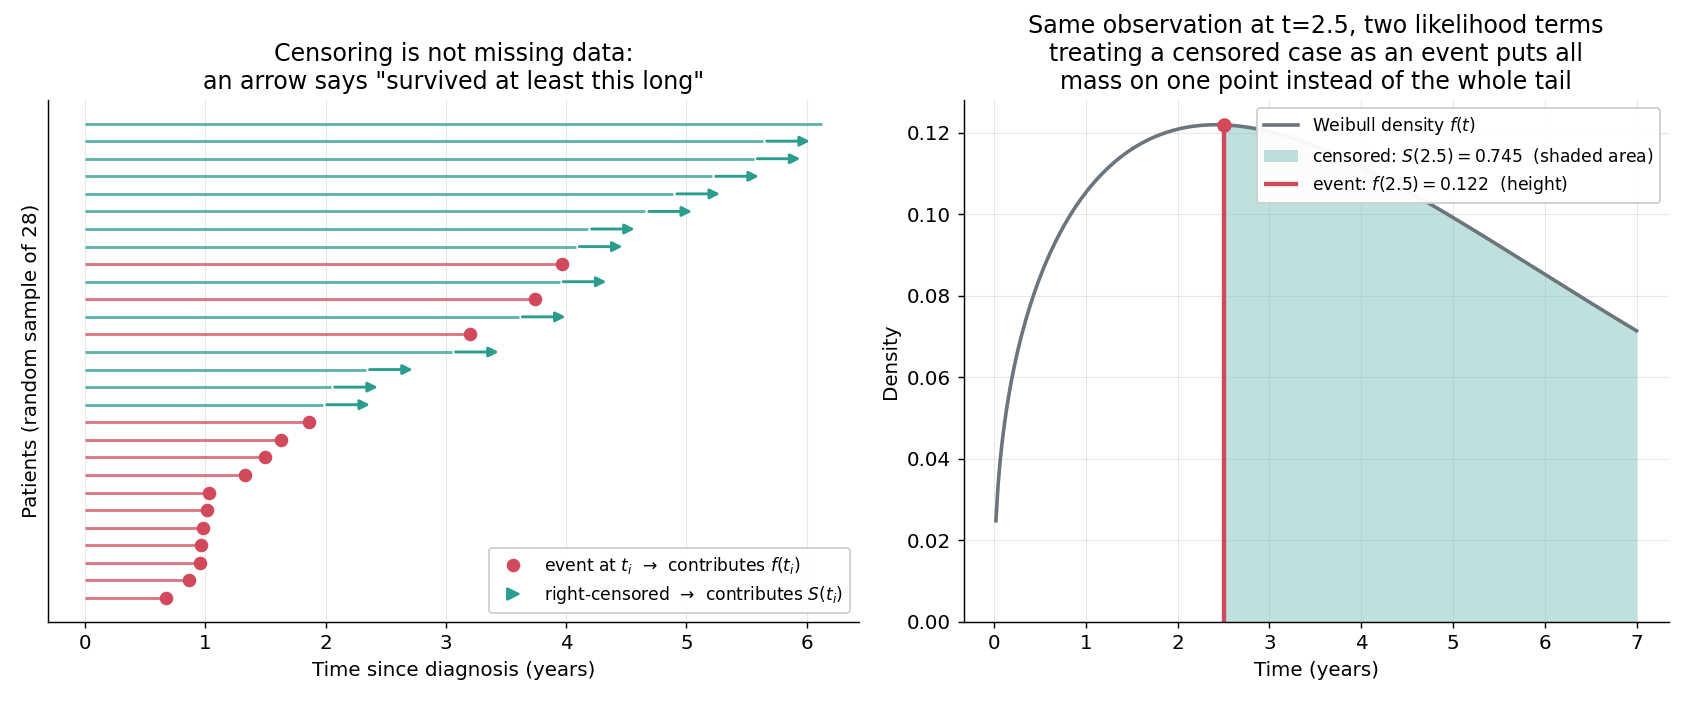

In [3]:
display(Image(os.path.join(FIG, '01_censoring_likelihood.png')))

## 3. 手刻似然,並驗證 `pm.Censored` 真的在算這件事

`pm.Censored` 是個黑箱。手刻的目的不是取代它,而是**確認自己知道它在算什麼** ——
如果不能重現它,就無法在它出錯(或我把參數化搞錯)時發現。

驗證方式是**逐點**比對 log-likelihood,不只比總和:總和相同但逐點不同,
會是相互抵消的錯誤。

In [4]:
rng = np.random.default_rng(0)
beta_probe = rng.normal(0, 0.3, s.X.shape[1])
lam_probe  = np.exp(1.6 + s.X @ beta_probe)   # 每個個體不同的 λ_i

rows = []
for kind, params in [('weibull', (1.4, lam_probe)),
                     ('lognormal', (0.9, lam_probe)),
                     ('exponential', (lam_probe,))]:
    r = cn.verify_equivalence(s.t, s.event, kind, params)
    rows.append(r)
chk = pd.DataFrame(rows)[['kind','passed','max_abs_err','total_loglik_mine',
                          'total_loglik_pymc','n_events','n_censored']]
display(chk)
print('三個分佈都逐點吻合到數值精度 → 手刻的刪失似然與 pm.Censored 等價。')
print('（LogNormal 的誤差稍大是 scipy 與 pytensor 的 erfc 實作差異,非邏輯錯誤。）')

,kind,passed,max_abs_err,total_loglik_mine,total_loglik_pymc,n_events,n_censored
0,weibull,True,2.220446e-16,-958.604461,-958.604461,299,387
1,lognormal,True,2.263530e-08,-1051.197457,-1051.197457,299,387
2,exponential,True,4.440892e-16,-937.659994,-937.659994,299,387


三個分佈都逐點吻合到數值精度 → 手刻的刪失似然與 pm.Censored 等價。
（LogNormal 的誤差稍大是 scipy 與 pytensor 的 erfc 實作差異,非邏輯錯誤。）


### 刪失那一項到底有多重要?

把 `pm.Censored` 的上界從「刪失筆 = 觀察時間」改成「全部 = ∞」,
就等於把刪失當成事件。兩者的 log-likelihood 差距就是刪失項的全部貢獻。

In [5]:
ll_correct = cn.censored_loglik(s.t, s.event, 'weibull', 1.4, lam_probe).sum()
ll_naive   = cn.censored_loglik(s.t, np.ones_like(s.event), 'weibull', 1.4, lam_probe).sum()
print(f"正確處理刪失   : log L = {ll_correct:10.2f}")
print(f"刪失當成事件   : log L = {ll_naive:10.2f}")
print(f"差距           : {ll_naive - ll_correct:+10.2f} nat  ({s.n_censored} 筆刪失)")
print()
demo = cn.censoring_information_demo(2.5, 1.4, 4.5)
print(f"單一觀測在 t=2.5(k=1.4, λ=4.5):")
print(f"  當成事件 log f = {demo['logpdf_if_event']:.4f}")
print(f"  當成刪失 log S = {demo['logsf_if_censored']:.4f}   (S={demo['survival_prob']:.3f})")
print()
print('注意 log S > log f:存活到 t 的機率(尾巴面積)通常大於剛好在 t 死亡的密度。')
print('所以錯誤地當成事件會讓似然變小,而模型會靠「縮短存活時間」來補償。')

正確處理刪失   : log L =    -958.60
刪失當成事件   : log L =   -1656.48
差距           :    -697.88 nat  (387 筆刪失)

單一觀測在 t=2.5(k=1.4, λ=4.5):
  當成事件 log f = -1.8419
  當成刪失 log S = -0.4392   (S=0.645)

注意 log S > log f:存活到 t 的機率(尾巴面積)通常大於剛好在 t 死亡的密度。
所以錯誤地當成事件會讓似然變小,而模型會靠「縮短存活時間」來補償。


## 4. 通關標準 1:忽略刪失 → 存活時間被系統性低估

三種處理方式,同一個 Weibull AFT 模型:

| 做法 | 似然 | 用到的資料 |
|---|---|---|
| **正確** | 事件 $f(t_i)$、刪失 $S(t_i)$ | 686 筆全用 |
| **錯誤 B**:刪失當成事件 | 全部 $f(t_i)$ | 686 筆,但 387 筆的時間被當成死亡時間 |
| **錯誤 A**:丟掉刪失 | 全部 $f(t_i)$ | 只剩 299 筆事件 |

錯誤 A 的直覺是「資料不完整就不要用」,但被丟掉的正是活得久的那群人。
兩種錯誤的**機制不同,方向卻一樣**,都是低估。

下面的數字直接從完整重現流程的 `results.json` 讀出(先驗、鏈長都與 README 一致)。

In [6]:
ch = RES['censoring_handling']
km_med = RES['km_median_survival']
tbl = pd.DataFrame([
    {'做法': '正確處理刪失',    'n 用到': ch['correct']['n_used'],  '事件數': ch['correct']['events_used'],
     '中位存活(年)': ch['correct']['median'], '95% CrI': f"[{ch['correct']['lo']:.2f}, {ch['correct']['hi']:.2f}]",
     'vs KM 偏差': f"{ch['correct']['bias_vs_km_pct']:+.1f}%"},
    {'做法': '錯誤B:刪失當事件', 'n 用到': ch['as_event']['n_used'], '事件數': ch['as_event']['events_used'],
     '中位存活(年)': ch['as_event']['median'], '95% CrI': f"[{ch['as_event']['lo']:.2f}, {ch['as_event']['hi']:.2f}]",
     'vs KM 偏差': f"{ch['as_event']['bias_vs_km_pct']:+.1f}%"},
    {'做法': '錯誤A:丟掉刪失',   'n 用到': ch['drop']['n_used'],     '事件數': ch['drop']['events_used'],
     '中位存活(年)': ch['drop']['median'], '95% CrI': f"[{ch['drop']['lo']:.2f}, {ch['drop']['hi']:.2f}]",
     'vs KM 偏差': f"{ch['drop']['bias_vs_km_pct']:+.1f}%"},
])
display(tbl.round(3))
print(f"Kaplan–Meier 中位存活(正確處理刪失的非參數基準):{km_med:.2f} 年")

,做法,n 用到,事件數,中位存活(年),95% CrI,vs KM 偏差
0,正確處理刪失,686,299,4.620,"[3.89, 5.55]",-6.6%
1,錯誤B:刪失當事件,686,686,2.638,"[2.41, 2.90]",-46.7%
2,錯誤A:丟掉刪失,299,299,2.169,"[1.85, 2.53]",-56.2%


Kaplan–Meier 中位存活(正確處理刪失的非參數基準):4.95 年


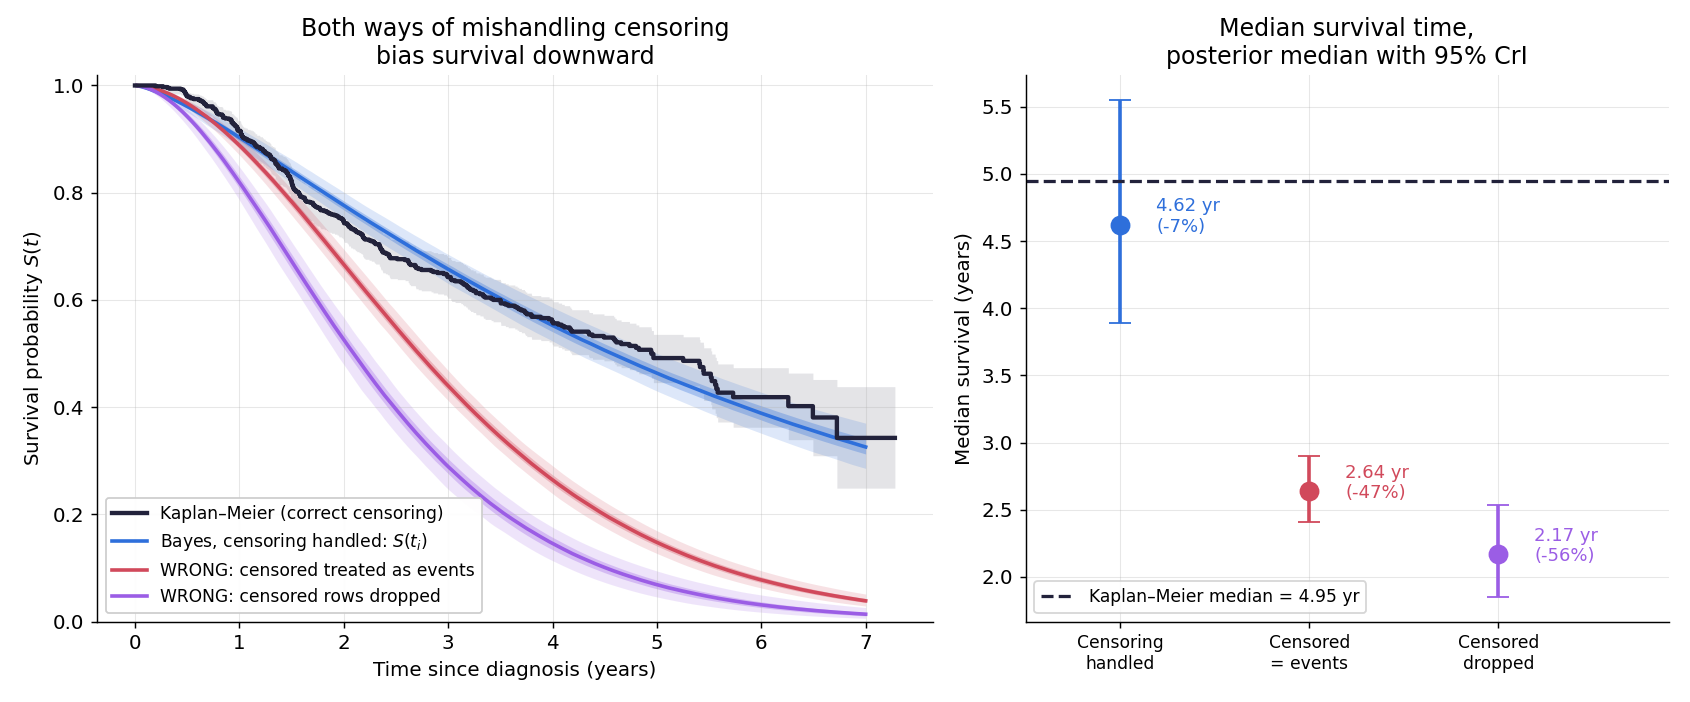

In [7]:
display(Image(os.path.join(FIG, '02_censoring_handling.png')))

左圖把三個族群存活曲線疊在 Kaplan–Meier 上。正確處理刪失的曲線貼著 KM;
兩條錯誤做法的曲線都掉到 KM 下方 —— **通關標準 1 達成**。

值得注意的是「丟掉刪失」比「刪失當事件」錯得更兇。兩者都低估,但前者
同時失去 56% 的樣本,連係數的精度都一起犧牲。

## 5. 通關標準 2:個體存活曲線 + 不確定性帶

貝葉斯的獨門好處:後驗不是一組參數,是一整族參數 → 對一個病人,
得到的不是一條存活曲線,是**一整族曲線**,取分位數就是不確定性帶。

Cox 的對照是結構性的,不是實作偷懶:Cox 用 partial likelihood 把基準風險
$h_0(t)$ 當成無窮維討厭參數消掉。好處是不必假設分佈形狀,代價是
**沒有 $h_0(t)$ 的估計就無法傳播它的不確定性** —— `predict_survival_function`
回傳的是把 Breslow 估計當成真值的一條線。

In [8]:
for tag in ['Low-risk patient', 'High-risk patient']:
    p = RES['patients'][tag]
    m = p['median_survival']
    bw = p['band_width_at_t']
    print(f"{tag}:  {p['desc']}")
    print(f"   中位存活 {m[0]:.2f} 年  95% CrI [{m[1]:.2f}, {m[2]:.2f}]"
          f"   (區間寬度 {m[2]-m[1]:.2f} 年)")
    print(f"   t={bw['t']:.1f} 年處 S(t) 的 95% 帶寬 = {bw['width']:.3f}")
    print()

Low-risk patient:  1 positive nodes, progesterone 120 fmol, hormone therapy: yes
   中位存活 10.30 年  95% CrI [7.84, 13.82]   (區間寬度 5.98 年)
   t=1.8 年處 S(t) 的 95% 帶寬 = 0.045

High-risk patient:  14 positive nodes, progesterone 6 fmol, hormone therapy: no
   中位存活 1.94 年  95% CrI [1.57, 2.40]   (區間寬度 0.84 年)
   t=1.8 年處 S(t) 的 95% 帶寬 = 0.200



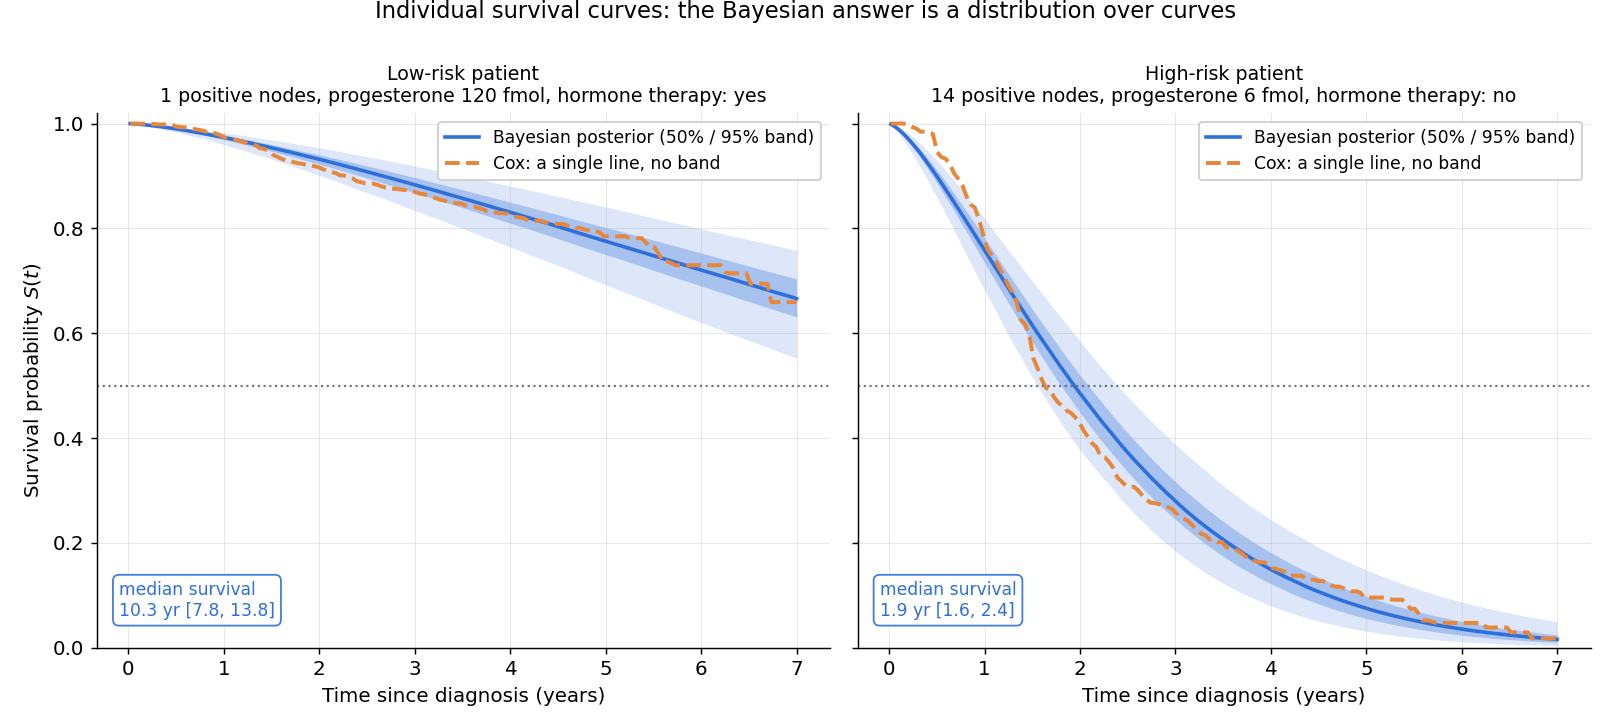

In [9]:
display(Image(os.path.join(FIG, '03_individual_survival.png')))

兩位病人的帶寬不同,而且高風險病人的帶更寬 —— 這正是決策時需要知道的事:
「這個預測有多可信」隨病人而異,單一條 Cox 曲線無法表達。**通關標準 2 達成**。

## 6. 對照頻率派:同樣的數字,不同的意義

Weibull 是**唯一同時是 AFT 也是 PH 的分佈族**之一,所以 AFT 係數可以換算成
hazard ratio,直接跟 Cox 並排:

$$h(t|x) = \frac{k}{\lambda^k}t^{k-1},\quad \lambda=e^{\beta_0+x\beta_{AFT}}
\;\Longrightarrow\; h(t|x) = k\,t^{k-1}e^{-k(\beta_0+x\beta_{AFT})}$$

$x$ 的效應是與 $t$ 無關的乘性因子 → 這正是 PH 結構,且
$$\boxed{\beta_{PH} = -k\,\beta_{AFT}}$$

換算後與 Cox 的 partial likelihood 估計比對,是對兩邊實作的交叉驗證。

In [10]:
cmp_rows = []
for f, v in RES['aft_to_ph_vs_cox'].items():
    cmp_rows.append({
        '特徵': D.LABELS[f],
        'Bayes β_PH': v['bayes_ph_median'],
        'Bayes 95% CrI': f"[{v['bayes_lo95']:+.3f}, {v['bayes_hi95']:+.3f}]",
        'Cox log HR': v['cox_log_hr'],
        'Cox 95% CI': f"[{v['cox_lo95']:+.3f}, {v['cox_hi95']:+.3f}]",
        '|差|': v['abs_diff'],
        '區間寬度比': v['ci_width_ratio'],
    })
display(pd.DataFrame(cmp_rows).round(4))
print(f"平均 |差| = {RES['aft_to_ph_mean_abs_diff']:.4f},最大 = {RES['aft_to_ph_max_abs_diff']:.4f}")
print()
print(f"頻率派 Weibull AFT 的 MLE shape ρ = {RES['weibull_aft_mle_rho']:.3f}")
print(f"貝葉斯後驗 k              = {RES['weibull_shape_k']['median']:.3f} "
      f"[{RES['weibull_shape_k']['lo95']:.3f}, {RES['weibull_shape_k']['hi95']:.3f}]")
print()
print('數字幾乎重合 → 先驗確實是弱資訊的,沒有偷偷主導結論。')
print('這件事本身就是結論:資料充足時兩派收斂,貝葉斯的價值不在「答案不同」,')
print('而在(a)答案能被正確地當成機率解讀、(b)能自然傳播到個體預測與下游決策。')

,特徵,Bayes β_PH,Bayes 95% CrI,Cox log HR,Cox 95% CI,|差|,區間寬度比
0,Age,-0.0747,"[-0.246, +0.097]",-0.0853,"[-0.264, +0.094]",0.0106,0.9585
1,log Tumor size,0.0797,"[-0.039, +0.195]",0.0734,"[-0.045, +0.192]",0.0063,0.9828
2,log Positive nodes,0.4613,"[+0.347, +0.577]",0.4489,"[+0.333, +0.565]",0.0124,0.9936
3,log Progesterone rec.,-0.3718,"[-0.524, -0.220]",-0.3768,"[-0.533, -0.220]",0.0050,0.9695
4,log Estrogen rec.,0.0677,"[-0.084, +0.217]",0.0659,"[-0.088, +0.220]",0.0019,0.9759
5,Tumor grade (ord.),0.1081,"[-0.014, +0.232]",0.1026,"[-0.024, +0.229]",0.0055,0.9733
6,Hormone therapy,-0.3854,"[-0.634, -0.148]",-0.3743,"[-0.627, -0.122]",0.0111,0.9632
7,Postmenopausal,0.1863,"[-0.146, +0.533]",0.1958,"[-0.162, +0.553]",0.0095,0.9512


平均 |差| = 0.0078,最大 = 0.0124

頻率派 Weibull AFT 的 MLE shape ρ = 1.423
貝葉斯後驗 k              = 1.391 [1.260, 1.528]

數字幾乎重合 → 先驗確實是弱資訊的,沒有偷偷主導結論。
這件事本身就是結論:資料充足時兩派收斂,貝葉斯的價值不在「答案不同」,
而在(a)答案能被正確地當成機率解讀、(b)能自然傳播到個體預測與下游決策。


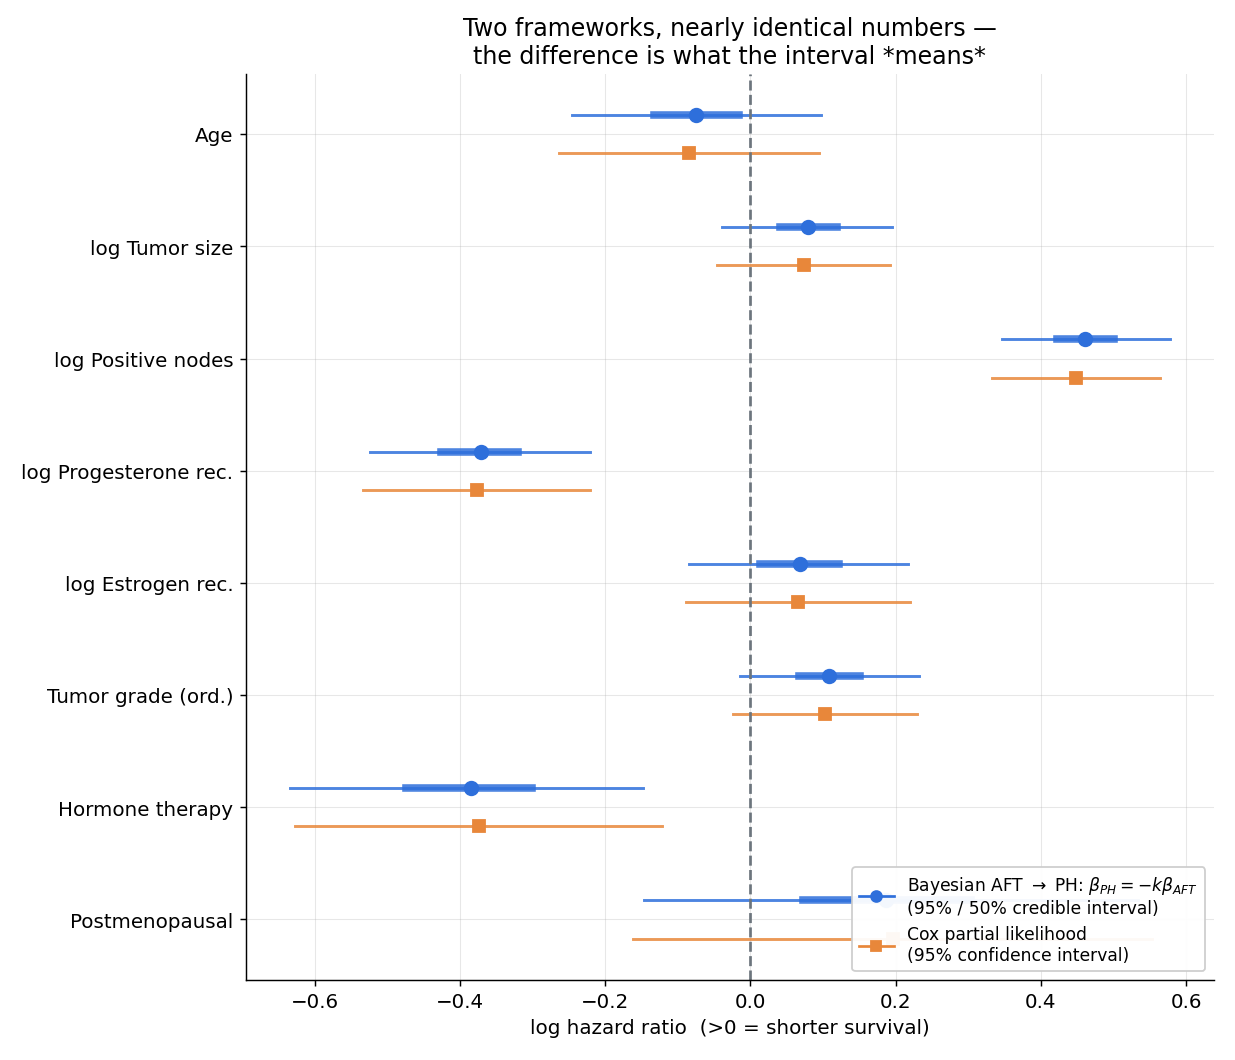

In [11]:
display(Image(os.path.join(FIG, '06_bayes_vs_cox.png')))

### 區間的意義不同(主題三)

| | 95% 信賴區間(Cox) | 95% 可信區間(貝葉斯) |
|---|---|---|
| 機率屬於 | **程序**:重複研究很多次,95% 的區間會覆蓋真值 | **參數**:給定這筆資料與先驗,參數在區間內的機率是 95% |
| 對手上這一個區間 | 不能說「有 95% 機率落在裡面」 | 可以 |
| 能否直接進決策 | 需要額外論證 | 直接可以(對後驗積分即期望損失) |

數值上兩者在這份資料幾乎一樣;**意義上不同**,而下游要做決策時,意義才是重點。

### 誠實檢查:比例風險假設站得住嗎?

我的 Weibull AFT 是 PH 模型,Cox 也是。如果 PH 假設被違反,**兩邊一起錯**。
用 Schoenfeld 殘差檢定。

In [12]:
ph = pd.DataFrame(RES['ph_test']).T
ph.index = [D.LABELS.get(i, i) for i in ph.index]
display(ph.round(4))
mn = ph['p'].min()
print(f"最小 p = {mn:.3f}")
print('沒有特徵在 0.05 下明確違反,但 age 與 tumour grade 接近邊界(p≈0.05),')
print('代表它們的風險比可能隨時間變化。這一點寫進 README 的限制章節。')

,test_statistic,p
Age,3.7541,0.0527
log Tumor size,0.0574,0.8107
log Positive nodes,0.8856,0.3467
log Progesterone rec.,0.0667,0.7962
log Estrogen rec.,1.8509,0.1737
Tumor grade (ord.),3.6833,0.0550
Hormone therapy,0.2253,0.6350
Postmenopausal,0.0033,0.9540


最小 p = 0.053
沒有特徵在 0.05 下明確違反,但 age 與 tumour grade 接近邊界(p≈0.05),
代表它們的風險比可能隨時間變化。這一點寫進 README 的限制章節。


## 小結

- 刪失似然:事件貢獻 $f(t_i)$、右刪失貢獻 $S(t_i)$。手刻與 `pm.Censored` 逐點等價。
- **通關標準 1 ✅**:兩種忽略刪失的做法都讓存活時間系統性低估。
- **通關標準 2 ✅**:貝葉斯給一整族個體存活曲線,Cox 只給一條線。
- AFT → PH 換算後與 Cox 幾乎重合,交叉驗證了兩邊的實作與弱資訊先驗的無害性。

下一本:**模型比較(WAIC/LOO)** 與**刪失的資訊代價** —— 後者的實測結果
推翻了「精度只由事件數決定」這句常見的簡化說法。